# PyRadtran Quickstart

This notebook walks through the **recommended pyRadtran workflow** from
scratch:

1. **One-time setup** — write machine-specific paths to the *master
   config* (`~/.pyradtran/config.yaml`).
2. **Build a simulation config in Python** and save it as a `.yaml`
   file — so you always know exactly what settings were used.
3. **Run the simulation** via the xarray accessor
   `ds.pyradtran.run(config_path=...)`.
4. **Inspect the generated `uvspec` input file** — the bridge between
   your Python dict and the actual libRadtran call.
5. **Visualise the results.**

> **Config cascade (later layers win):**  
> Package defaults → `~/.pyradtran/config.yaml` (master) → simulation YAML


In [ ]:
import logging
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# pyRadtran public API
from pyradtran import (
    load_config,
    save_master_config,
    list_solar_spectra,
    list_atmosphere_profiles,
    SOLAR_SPECTRA,
    ATMOSPHERE_PROFILES,
)
from pyradtran.interface import PyRadtranAccessor  # registers ds.pyradtran

# Adjust to DEBUG if you want to see every uvspec call
logging.getLogger('pyradtran').setLevel(logging.INFO)

print("pyRadtran imported successfully.")


pyRadtran imported successfully.


## Step 1 — One-time master config setup

Run this cell **once** to store your libRadtran installation paths in
`~/.pyradtran/config.yaml`.  Every subsequent simulation YAML you write
can omit these paths; they will be picked up automatically.


In [24]:
# ── Edit the paths below to match YOUR libRadtran installation ──────────────
LIBRADTRAN_BIN  = "/opt/libRadtran-2.0.6/bin/uvspec"
LIBRADTRAN_DATA = "/opt/libRadtran-2.0.6/data"

# atmosphere_profile and solar_spectrum accept short names (see cell below)
# or full absolute paths.
master_path = save_master_config(
    libradtran_bin=LIBRADTRAN_BIN,
    libradtran_data=LIBRADTRAN_DATA,
    atmosphere_profile="afglus",      # short name → data/atmmod/afglus.dat
    solar_spectrum="NewGuey2003",    # short name → data/solar_flux/NewGuey2003.dat
    output_dir="./pyradtran_output",
    working_dir="./pyradtran_work",
)

print(f"Master config written to: {master_path}")
print()
print("Contents:")
print(master_path.read_text())


2026-04-18 16:57:26,527 - pyradtran.config - INFO - Master config saved to /home/josh/.pyradtran/config.yaml


Master config saved to: /home/josh/.pyradtran/config.yaml
Master config written to: /home/josh/.pyradtran/config.yaml

Contents:
paths:
  atmosphere_profile: afglus
  libradtran_bin: /opt/libRadtran-2.0.6/bin/uvspec
  libradtran_data: /opt/libRadtran-2.0.6/data
  output_dir: ./pyradtran_output
  solar_spectrum: NewGuey2003
  working_dir: ./pyradtran_work



### Available solar spectra and atmosphere profiles

pyRadtran ships a built-in catalog of the files bundled with libRadtran.
Pass any short name to `save_master_config()`, `PathsConfig`, or directly
to a simulation config — pyRadtran will resolve it to the full path under
`libradtran_data` automatically.

In [25]:
print("── Solar spectra ──────────────────────────────────────────────────────")
list_solar_spectra()
print()
print("── Atmosphere profiles ────────────────────────────────────────────────")
list_atmosphere_profiles()

── Solar spectra ──────────────────────────────────────────────────────
Short name            Description
----------------------------------------------------------------------
  kurudz_1.0nm        Kurucz (1985) solar spectrum, 1 nm resolution, 250–10000 nm
  kurudz_0.1nm        Kurucz (1985) solar spectrum, 0.1 nm resolution
  NewGuey2003         Gueymard (2003) high-resolution solar spectrum
  Thekaekara          Thekaekara (1974) solar spectrum

── Atmosphere profiles ────────────────────────────────────────────────
Short name              Description
----------------------------------------------------------------------
  afglus                US Standard Atmosphere 1976
  afglms                Mid-latitude Summer
  afglmw                Mid-latitude Winter
  afglt                 Tropical
  afglss                Sub-arctic Summer
  afglsw                Sub-arctic Winter
  mcclams               McClatchey Mid-latitude Summer (extended)
  mcclamw               McClatchey Mid-latit

## Step 2 — Build the simulation config in Python

Instead of hand-editing a YAML file, we define the simulation settings
right here in Python.  This makes the notebook **self-documenting**: the
reader can see every parameter and its value at a glance.

After editing, we call `cfg.to_yaml()` to persist it.  The saved YAML
is what gets passed to `ds.pyradtran.run()`; it is merged on top of the
master config, so paths do not need to be repeated.


In [26]:
# ── Simulation parameters ────────────────────────────────────────────────────
# Start from the merged package defaults + master config, then customise.
cfg = load_config()  # reads ~/.pyradtran/config.yaml + package defaults

# Spectral range
cfg.simulation_defaults.wavelength_nm        = [350, 2500]
cfg.simulation_defaults.mol_abs_param        = "lowtran per_nm"
cfg.simulation_defaults.rte_solver           = "twostr"
cfg.simulation_defaults.source               = "solar"
cfg.simulation_defaults.integrate_wavelength = False

# Output columns and altitude(s)
cfg.simulation_defaults.output_columns       = ["lambda", "edir", "edn", "eup"]
cfg.simulation_defaults.output_altitudes_km  = [0.0]

# Surface
cfg.simulation_defaults.albedo_value         = 0.15

# Atmosphere
cfg.simulation_defaults.ozone_du             = 300.0
cfg.simulation_defaults.h2o_mm               = 2.0
cfg.simulation_defaults.h2o_source           = "fixed"

# Clouds: disabled for this quickstart
cfg.simulation_defaults.clouds.enabled       = False

# Execution
cfg.execution.max_workers      = 1
cfg.execution.cleanup_temp_files = False   # keep .inp files so we can inspect them

# ── Save to YAML ─────────────────────────────────────────────────────────────
config_path = Path("config/quickstart.yaml")
cfg.to_yaml(config_path)
print(f"Simulation config saved to: {config_path.resolve()}")


2026-04-18 16:57:31,202 - pyradtran.config - INFO - Configuration written to config/quickstart.yaml


Simulation config saved to: /home/josh/pyRadtran/book/notebooks/config/quickstart.yaml


In [27]:
# ── Inspect the saved YAML ───────────────────────────────────────────────────
print(f"─── {config_path} ───")
print(config_path.read_text())


─── config/quickstart.yaml ───
execution:
  cleanup_temp_files: false
  debug_mode: false
  max_workers: 1
  timeout_seconds: 300
output:
  filename_prefix: pyradtran_sim
  filename_suffix: _results.nc
  netcdf_encoding:
    complevel: 5
    zlib: true
paths:
  atmosphere_profile: /opt/libRadtran-2.0.6/data/atmmod/afglus.dat
  libradtran_bin: /opt/libRadtran-2.0.6/bin/uvspec
  libradtran_data: /opt/libRadtran-2.0.6/data
  output_dir: pyradtran_output
  radiosonde_base: /path/to/radiosonde/data
  solar_spectrum: /opt/libRadtran-2.0.6/data/solar_flux/NewGuey2003.dat
  working_dir: pyradtran_work
simulation_defaults:
  albedo_value: 0.15
  clouds:
    cloud_fraction: 1.0
    cloud_source: parametric
    cloud_type: wc
    effective_radius_um: 10.0
    enabled: false
    era5_lat: null
    era5_lon: null
    era5_time: null
    ic_file: null
    ice_content_g_m3: 0.0
    layer_bottom_km: 1.0
    layer_top_km: 2.0
    water_content_g_m3: 0.1
    wc_file: null
  h2o_mm: 2.0
  h2o_source: fix

## Step 3 — Set up an xarray Dataset and run the simulation

We create a minimal xarray Dataset with `time`, `latitude`, and
`longitude` coordinates — one row per simulation point — then call
`ds.pyradtran.run(config_path=...)`.

The accessor loads the saved YAML, merges the master config on top, and
dispatches `uvspec` in parallel for every point.


In [28]:
N = 6  # number of time steps

ds = xr.Dataset(
    coords={
        "time":      pd.date_range("2025-06-21T08:00:00", periods=N, freq="2h"),
        "latitude":  ("time", [61.0] * N),
        "longitude": ("time", [22.0] * N),
    }
)

print("Input dataset:")
print(ds)
print()

ds_sim = ds.pyradtran.run(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
)

print("\nSimulation complete!")
print(f"Output variables : {list(ds_sim.data_vars)}")
print(f"Output coords    : {list(ds_sim.coords)}")
print(f"Dataset shape    : {dict(ds_sim.dims)}")


2026-04-18 16:57:34,449 - pyradtran.interface - INFO - Auto-generating output path: pyradtran_output/pyradtran_sim_20260418_165734_results.nc
2026-04-18 16:57:34,450 - pyradtran.interface - INFO - Preparing 6 simulations from input dataset with dims ['time']


Input dataset:
<xarray.Dataset> Size: 144B
Dimensions:    (time: 6)
Coordinates:
  * time       (time) datetime64[ns] 48B 2025-06-21T08:00:00 ... 2025-06-21T1...
    latitude   (time) float64 48B 61.0 61.0 61.0 61.0 61.0 61.0
    longitude  (time) float64 48B 22.0 22.0 22.0 22.0 22.0 22.0
Data variables:
    *empty*



Running simulations: 100%|██████████| 6/6 [00:03<00:00,  1.53sim/s, Success=6, Total=6]
2026-04-18 16:57:38,373 - pyradtran.interface - INFO - Batch execution completed: 6/6 simulations successful
2026-04-18 16:57:38,384 - pyradtran.io - INFO - Results saved to pyradtran_output/pyradtran_sim_20260418_165734_results.nc
2026-04-18 16:57:38,385 - pyradtran.interface - INFO - Results saved to pyradtran_output/pyradtran_sim_20260418_165734_results.nc



Simulation complete!
Output variables : ['lambda', 'edir', 'edn', 'eup']
Output coords    : ['time', 'wavelength', 'altitude']
Dataset shape    : {'time': 6, 'wavelength': 1565, 'altitude': 1}


/tmp/ipykernel_91671/2030586749.py:24: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dataset shape    : {dict(ds_sim.dims)}")


## Step 4 — Inspect the generated `uvspec` input file

Every simulation produces a temporary `.inp` file in the `working_dir`.
Reading the first one shows you exactly how the Python dict → YAML →
`uvspec` input pipeline works.


In [29]:
# The working directory is set in the config
working_dir = Path(cfg.paths.working_dir)

# Pick the most recently modified .inp file
inp_files = list(working_dir.glob("*.inp"))

if inp_files:
    latest_inp = max(inp_files, key=lambda p: p.stat().st_mtime)
    print(f"─── {latest_inp.name} (latest generated input file) ───\n")
    print(latest_inp.read_text())
else:
    print("No .inp files found – make sure cleanup_temp_files=False in the config.")


─── tmpz6vhou60.inp (latest generated input file) ───

rte_solver twostr
mol_abs_param lowtran per_nm
data_files_path /opt/libRadtran-2.0.6/data
atmosphere_file /opt/libRadtran-2.0.6/data/atmmod/afglus.dat
source solar /opt/libRadtran-2.0.6/data/solar_flux/NewGuey2003.dat
sza 79.55
day_of_year 172
wavelength 350 2500
albedo 0.15
output_user lambda edir edn eup
zout 0.0000
umu 1.0
quiet



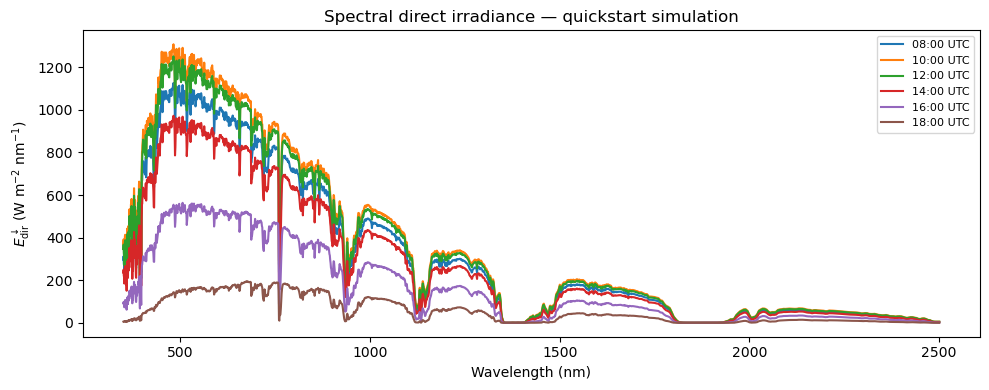

In [31]:
## Step 5 — Visualise the results

fig, ax = plt.subplots(figsize=(10, 4))
for i, t in enumerate(ds_sim.time.values):
    label = pd.Timestamp(t).strftime("%H:%M UTC")
    ds_sim.isel(time=i)["edir"].plot(ax=ax, label=label)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel(r"$E_\mathrm{dir}^\downarrow$ (W m$^{-2}$ nm$^{-1}$)")
ax.set_title("Spectral direct irradiance — quickstart simulation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
